In [ ]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)
    break

: 

In [ ]:
import pandas as pd

CSV_PATH = "/kaggle/input/datasets/dreamer07/eyepacs/trainLabels.csv/trainLabels.csv"

df = pd.read_csv(CSV_PATH)

print(df.head())
print(df.shape)
print(df['level'].value_counts().sort_index())

In [ ]:
import os
from PIL import Image
from tqdm import tqdm
from multiprocessing import Pool

RESIZED_DIR = "/kaggle/working/resized_images"
os.makedirs(RESIZED_DIR, exist_ok=True)

def process_image(img_name):
    src_path = os.path.join(IMG_DIR, img_name + ".jpeg")
    dst_path = os.path.join(RESIZED_DIR, img_name + ".jpeg")
    if not os.path.exists(dst_path) and os.path.exists(src_path):
        with Image.open(src_path) as img:
            img = img.resize((150, 150))
            img.save(dst_path, quality=85) # Faster write with light compression

if __name__ == "__main__":
    # Use all available CPU threads
    num_workers = os.cpu_count() or 4
    image_names = balanced_df["image"].values
    
    with Pool(num_workers) as p:
        list(tqdm(p.imap(process_image, image_names), total=len(image_names)))

In [ ]:
import os

for dirname, _, filenames in os.walk('/kaggle/input/datasets/dreamer07/eyepacs'):
    print(dirname)
    if len(filenames) > 0:
        print("Sample file:", filenames[0])
        break

In [ ]:
import torch

print("CUDA Available:", torch.cuda.is_available())
print("GPU Count:", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(torch.cuda.get_device_name(i))

In [ ]:
import pandas as pd
import numpy as np
from sklearn.utils import resample

In [ ]:
CSV_PATH = "/kaggle/input/datasets/dreamer07/eyepacs/trainLabels.csv/trainLabels.csv"

df = pd.read_csv(CSV_PATH)

print(df.shape)
print(df['level'].value_counts().sort_index())

In [ ]:
target_counts = {
    0: 20000,
    1: 15000,
    2: 10000,
    3: 7000,
    4: 7000
}

balanced_parts = []

for cls, target in target_counts.items():

    cls_df = df[df.level == cls]

    if len(cls_df) > target:

        cls_df = resample(
            cls_df,
            replace=False,
            n_samples=target,
            random_state=42
        )

    else:

        cls_df = resample(
            cls_df,
            replace=True,
            n_samples=target,
            random_state=42
        )

    balanced_parts.append(cls_df)

balanced_df = pd.concat(balanced_parts)
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(balanced_df.shape)
print(balanced_df['level'].value_counts().sort_index())

In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    balanced_df,
    test_size=0.2,
    stratify=balanced_df['level'],
    random_state=42
)

print(train_df.shape)
print(val_df.shape)

In [ ]:
import os
import cv2
import torch
import timm
import numpy as np
import pandas as pd

from PIL import Image
from tqdm import tqdm

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import accuracy_score
from sklearn.metrics import cohen_kappa_score

from torch import nn
from torch.utils.data import Dataset, DataLoader

from torch.amp import autocast, GradScaler

In [ ]:
CSV_PATH = "/kaggle/input/datasets/dreamer07/eyepacs/trainLabels.csv/trainLabels.csv"
# Point directly to your resized output folder
IMG_DIR = "/kaggle/working/resized_images"
BATCH_SIZE = 64
EPOCHS = 25
LR = 1e-3
NUM_CLASSES = 5
DEVICE = "cuda"

In [ ]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.ColorJitter(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

In [ ]:
class EyePACSDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_id = self.df.loc[idx, "image"]
        label = self.df.loc[idx, "level"]
        img_path = os.path.join(self.img_dir, image_id + ".jpeg")
        
        # Fast OpenCV read
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(f"Image not found: {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image=image)["image"]

        return image, label

In [ ]:
train_dataset = EyePACSDataset(
    train_df,
    IMG_DIR,
    train_transform
)

val_dataset = EyePACSDataset(
    val_df,
    IMG_DIR,
    val_transform
)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

print(len(train_loader))
print(len(val_loader))

In [ ]:
model = timm.create_model(
    "efficientnet_b3",
    pretrained=True,
    num_classes=5
)

# Send directly to primary GPU without DataParallel wrapper
model = model.to(DEVICE)

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

scaler = GradScaler("cuda")

In [ ]:
def validate(model, loader):
    model.eval()
    preds = []
    targets = []
    running_loss = 0.0
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            
            with autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            pred = outputs.argmax(1)
            preds.extend(pred.cpu().numpy())
            targets.extend(labels.cpu().numpy())
            
    # Placed OUTSIDE the for loop so it evaluates the whole validation set
    acc = accuracy_score(targets, preds)
    qwk = cohen_kappa_score(targets, preds, weights="quadratic")
    return (running_loss / len(loader), acc, qwk)

In [ ]:
best_qwk = 0.0
patience = 5
patience_counter = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{EPOCHS}")
    
    for images, labels in pbar:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        
        optimizer.zero_grad()
        with autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    # OUTSIDE the batch loop (runs ONCE per epoch after all batches finish)
    val_loss, val_acc, val_qwk = validate(model, val_loader)
    
    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]
    
    print(f"\nEpoch {epoch + 1}/{EPOCHS}"
          f"\nLR         : {current_lr:.6f}"
          f"\nTrain Loss : {train_loss / len(train_loader):.4f}"
          f"\nVal Loss   : {val_loss:.4f}"
          f"\nVal Acc    : {val_acc:.4f}"
          f"\nVal QWK    : {val_qwk:.4f}")

    if val_qwk > best_qwk:
        best_qwk = val_qwk
        patience_counter = 0
        torch.save(model.state_dict(), "best_efficientnet_b3.pth")
        print(f"Best Model Saved | QWK = {best_qwk:.4f}")
    else:
        patience_counter += 1
        print(f"No improvement in QWK. Early stopping counter: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print(f"\nEarly stopping triggered at Epoch {epoch + 1}!")
        break

print(f"\nTraining Complete! Best Validation QWK = {best_qwk:.4f}")

In [ ]:
import time

start = time.time()

for i, (images, labels) in enumerate(train_loader):
    if i == 100:
        break

elapsed = time.time() - start

print(f"100 batches took {elapsed:.2f} sec")
print(f"Per batch: {elapsed/100:.2f} sec")

In [ ]:
!nvidia-smi

In [ ]:
print(type(model))

In [73]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    cohen_kappa_score
)

model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(DEVICE)
        outputs = model(images)

        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.numpy())

acc = accuracy_score(all_targets, all_preds)

qwk = cohen_kappa_score(
    all_targets,
    all_preds,
    weights="quadratic"
)

print(f"Accuracy : {acc:.4f}")
print(f"QWK      : {qwk:.4f}")

print("\nClassification Report")
print(classification_report(all_targets, all_preds,target_names = classes))

print("\nConfusion Matrix")
print(confusion_matrix(all_targets, all_preds))

Accuracy : 0.9429
QWK      : 0.9472

Classification Report
                  precision    recall  f1-score   support

           No DR       0.94      0.90      0.92      4000
         Mild DR       0.96      0.99      0.98      3000
     Moderate DR       0.87      0.87      0.87      2000
       Severe DR       0.97      1.00      0.99      1400
Proliferative DR       0.99      1.00      0.99      1400

        accuracy                           0.94     11800
       macro avg       0.95      0.95      0.95     11800
    weighted avg       0.94      0.94      0.94     11800


Confusion Matrix
[[3610  123  247   13    7]
 [  15 2984    1    0    0]
 [ 219   10 1735   26   10]
 [   2    0    0 1397    1]
 [   0    0    0    0 1400]]


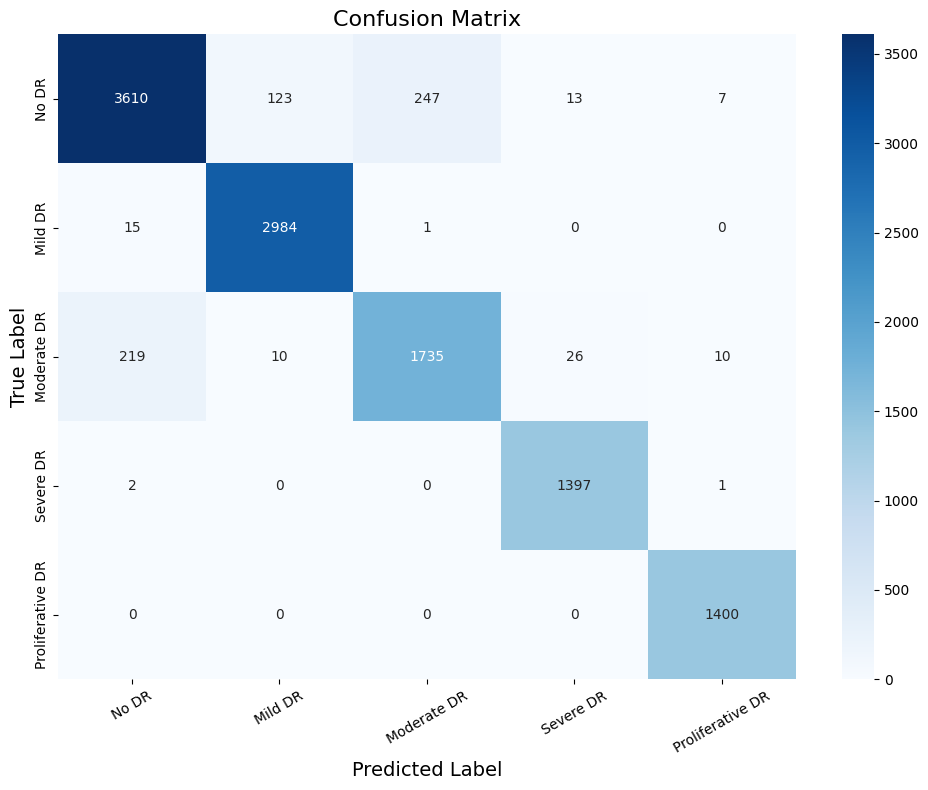

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Class names
classes = [
    "No DR",
    "Mild DR",
    "Moderate DR",
    "Severe DR",
    "Proliferative DR"
]

# Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)

# Plot
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.title("Confusion Matrix", fontsize=16)

plt.xticks(rotation=30)
plt.yticks(rotation=90)

plt.tight_layout()
plt.show()

Accuracy : 0.9429
QWK      : 0.9472

Classification Report
                  precision    recall  f1-score   support

           No DR       0.94      0.90      0.92      4000
         Mild DR       0.96      0.99      0.98      3000
     Moderate DR       0.87      0.87      0.87      2000
       Severe DR       0.97      1.00      0.99      1400
Proliferative DR       0.99      1.00      0.99      1400

        accuracy                           0.94     11800
       macro avg       0.95      0.95      0.95     11800
    weighted avg       0.94      0.94      0.94     11800



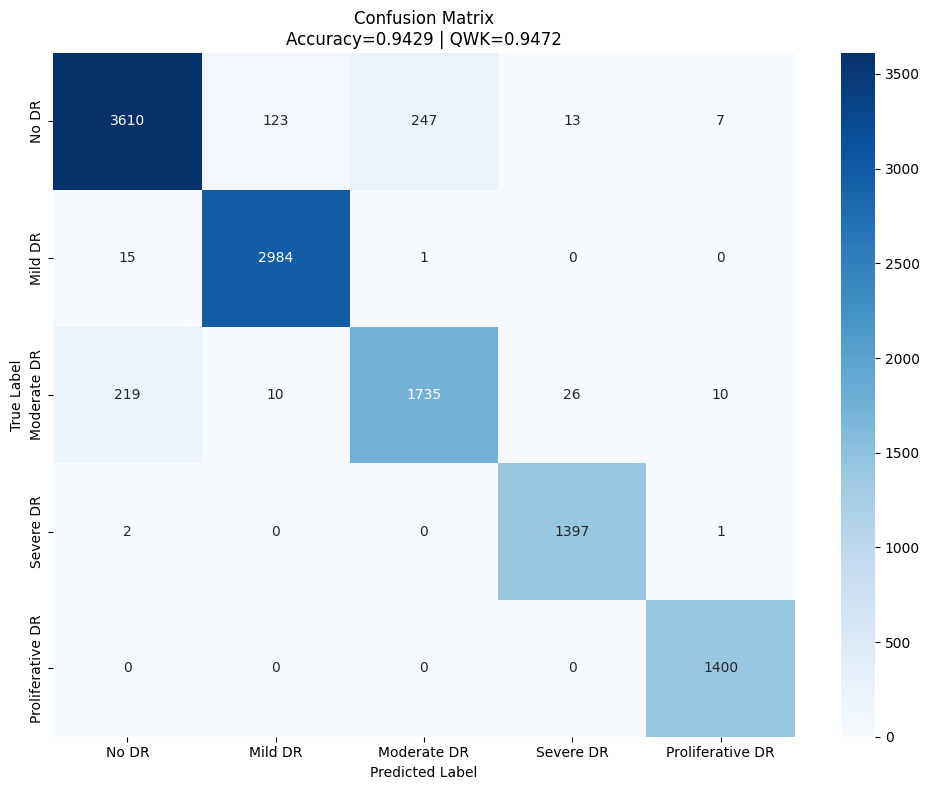

In [67]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    cohen_kappa_score
)

acc = accuracy_score(all_targets, all_preds)

qwk = cohen_kappa_score(
    all_targets,
    all_preds,
    weights="quadratic"
)

print(f"Accuracy : {acc:.4f}")
print(f"QWK      : {qwk:.4f}")

print("\nClassification Report")
print(classification_report(
    all_targets,
    all_preds,
    target_names=classes
))

# Confusion Matrix Plot
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix\nAccuracy={acc:.4f} | QWK={qwk:.4f}")

plt.tight_layout()
plt.show()

In [68]:
# Print Accuracy and QWK directly in notebook cell
acc = accuracy_score(all_targets, all_preds)
qwk = cohen_kappa_score(all_targets, all_preds, weights="quadratic")

print(f"Accuracy : {acc:.4f}")
print(f"QWK      : {qwk:.4f}")

Accuracy : 0.9429
QWK      : 0.9472


In [69]:
import shutil
from IPython.display import FileLink

# Compress the entire resized_images directory into a zip file
shutil.make_archive("resized_images", "zip", "/kaggle/working/resized_images")

# Display clickable browser download link
FileLink("resized_images.zip")

/kaggle/working/resized_images.zip

In [71]:
import os

# 1. Keep only images that actually exist in your resized folder
df["exists"] = df["image"].apply(
    lambda img_id: os.path.exists(os.path.join(IMG_DIR, img_id + ".jpeg"))
)
eval_df = df[df["exists"]].reset_index(drop=True)
print(f"Evaluating on {len(eval_df)} available resized images.")

# 2. Setup Dataset and Loader
full_dataset = EyePACSDataset(eval_df, IMG_DIR, val_transform)
full_loader = DataLoader(
    full_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=2, 
    pin_memory=True
)

# 3. Evaluate Model
model.eval()
all_full_preds = []
all_full_targets = []

with torch.no_grad():
    for images, labels in tqdm(full_loader, desc="Evaluating Available Images"):
        images = images.to(DEVICE)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        all_full_preds.extend(preds.cpu().numpy())
        all_full_targets.extend(labels.numpy())

# 4. Compute & Display Metrics
full_acc = accuracy_score(all_full_targets, all_full_preds)
full_qwk = cohen_kappa_score(all_full_targets, all_full_preds, weights="quadratic")

print(f"\n--- Evaluation Results ---")
print(f"Accuracy : {full_acc:.4f}")
print(f"QWK      : {full_qwk:.4f}\n")

classes = ["No DR", "Mild DR", "Moderate DR", "Severe DR", "Proliferative DR"]
print("Classification Report:")
print(classification_report(all_full_targets, all_full_preds, target_names=classes))

Evaluating on 29799 available resized images.


Evaluating Available Images: 100%|██████████| 466/466 [00:38<00:00, 11.95it/s]


--- Evaluation Results ---
Accuracy : 0.9701
QWK      : 0.9488

Classification Report:
                  precision    recall  f1-score   support

           No DR       0.99      0.98      0.98     21143
         Mild DR       0.93      1.00      0.96      2439
     Moderate DR       0.93      0.92      0.92      4636
       Severe DR       0.95      1.00      0.97       873
Proliferative DR       0.97      1.00      0.99       708

        accuracy                           0.97     29799
       macro avg       0.95      0.98      0.97     29799
    weighted avg       0.97      0.97      0.97     29799



aptos dataset